In [3]:
import os
import numpy as np
import torch
import time

from torch.optim import AdamW, lr_scheduler
from torch.nn import CrossEntropyLoss
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.decomposition import TruncatedSVD

import matplotlib.pyplot as plt

In [63]:
def make_val_loader_imagenet(val_dir: str, 
                             batch_size: int = 256, 
                             num_workers: int = 4):
    """
    Create ImageNet validation DataLoader with required transforms.
    """
    transforms_val = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        ),
    ])

    imagenet_val = datasets.ImageNet(
        root=val_dir, 
        split="val", 
        transform=transforms_val
    )

    return DataLoader(
        imagenet_val, 
        batch_size=batch_size, 
        shuffle=False,
        num_workers=num_workers, 
        pin_memory=True             # faster data transfer to GPU
    )


def make_train_loader_cifar100(data_dir: str, 
                               batch_size: int = 256, 
                               num_workers: int = 4):
    """
    Create CIFAR-100 training DataLoader for fine-tuning with dataset-specific transforms.
    """
    transforms_train = transforms.Compose([
        transforms.RandomCrop(32),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5071, 0.4867, 0.4408],
            std=[0.2675, 0.2565, 0.2761]
        )
    ])
    
    cifar100_val = datasets.CIFAR100(
        root=data_dir,
        train=True,
        download=True,
        transform=transforms_train
    )
    
    return DataLoader(
        cifar100_val,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

def make_val_loader_cifar100(data_dir: str, 
                             batch_size: int = 256, 
                             num_workers: int = 4):
    """
    Create CIFAR-100 validation DataLoader with dataset-specific transforms.
    """
    transforms_val = transforms.Compose([
        transforms.Resize(32),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5071, 0.4867, 0.4408],
            std=[0.2675, 0.2565, 0.2761]
        )
    ])
    
    cifar100_val = datasets.CIFAR100(
        root=data_dir,
        train=False,
        download=True,
        transform=transforms_val
    )
    
    return DataLoader(
        cifar100_val,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )


@torch.inference_mode()
def validate(model: torch.nn.Module, 
             loader: DataLoader, 
             device: torch.device):
    """
    Runs validation and returns top-1 and top-5 accuracy percentages.
    """
    model.eval()
    top1_correct = 0
    top5_correct = 0
    total = 0

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        logits = model(images)
        # get top-5 predictions
        _, preds = logits.topk(5, dim=1, largest=True, sorted=True)

        # compare with targets 
        # predictions: [batch,5]  targets: [batch]
        correct = preds.eq(targets.view(-1, 1))
        top1_correct += correct[:, :1].sum().item()
        top5_correct += correct.sum().item()
        total += targets.size(0)

    return top1_correct / total * 100.0, \
           top5_correct / total * 100.0

def val_top1_top5(model: torch.nn.Module,
                  val_loader: DataLoader, 
                  device: torch.device = torch.device("cpu")):
    top1, top5 = validate(model, val_loader, device)
    print("Top-1 Accuracy:", top1)
    print("Top-5 Accuracy:", top5)


def binarize_hook(module, input):
    """
    Forward-pre-hook for avgpool: replace input tensor by its sign (−1,0,+1).
    """
    x, = input
    #return (2**(x+1).log2().round()-1,) #-0.1%
    return (2**((x+1).log2().mul(2).round().mul(0.5)) - 1,) #-0.01% for ResNet50 on CIFAR-10

def fuse_avgpool_linear(model):
    W = model.fc.weight.data  # [1000, 368]
    b = model.fc.bias.data if model.model.fc.bias is not None else torch.zeros(W.shape[0])
    
    with torch.no_grad():
        dummy = torch.randn(1, 3, 224, 224).to(next(model.parameters()).device)
        features = model.stem[0](dummy)
        features = model.model.trunk_output[:-1](features)
        features = model.model.trunk_output[-1](features)
        features = model.model.avgpool(features)
        H, W = features.shape[-2:]
    
    divisor = H * W
    W_fused = W.repeat(1, divisor) / divisor
    
    return W_fused.cpu().numpy(), b.cpu().numpy()

In [ ]:
def plot_metrics(trains: list, 
                 tests: list, 
                 epochs: int, 
                 metric_name: str = "metric",
                 graph_dir: str = "graphs"):
    
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.plot(
        trains, 
        "b.-", alpha=0.6, lw=0.3, ms=0.8,
        label="train " + metric_name
    )
    ax.plot(
        [i * len(trains)//len(tests) for i in range(len(tests))], 
        tests, 
        "r.-", alpha=0.8, lw=0.3,
        label="test " + metric_name
    )
    ax.set_ylabel(metric_name)
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend()
    plt.savefig(os.path.join(graph_dir, f"regnet_{metric_name}_{epochs}epochs.png"))

In [53]:
def finetuning(model: torch.nn.Module,
               train_loader: DataLoader, 
               test_loader: DataLoader,
               device: torch.device = torch.device("cpu"),
               epochs: int = 150):
    model.to(device)
    
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    best_acc = 0
    max_lr = 0.01 # 0.001
    weight_decay = 0.001 # 5e-4
    optimizer = AdamW(model.parameters(), lr=max_lr, weight_decay=weight_decay)
    criterion = CrossEntropyLoss()
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

    checkpoint_dir = "checkpoints"
    graph_dir = f"graphs_{epochs}epochs"
    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(graph_dir, exist_ok=True)
    
    for epoch in range(epochs):
        print(f"Epoch {epoch} started...")
        start_time = time.time()
        
        # training
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            train_losses.append(loss.item())
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
        
        train_acc = 100. * correct / total
        train_accs.append(train_acc)
        
        # validation
        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                test_losses.append(loss.item())
                
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
        
        test_acc = 100. * correct / total
        test_accs.append(test_acc)
        scheduler.step()
        
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "acc": test_acc
        }, os.path.join(checkpoint_dir, f"regnet_cifar100_last_{epochs}epochs.pth"))
        
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "acc": test_acc
            }, os.path.join(checkpoint_dir, f"regnet_cifar100_best_{epochs}epochs.pth"))
        
        epoch_time = time.time() - start_time
        print(f"Epoch: {epoch+1}/{epochs} | "
              f"Time: {epoch_time:.2f}s | "
              f"Train Loss: {train_loss/len(train_loader):.4f} | "
              f"Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss/len(test_loader):.4f} | "
              f"Test Acc: {test_acc:.2f}% | "
              f"LR: {scheduler.get_last_lr()[0]:.6f}")

    plot_metrics(train_losses, test_losses, epochs, metric_name="loss", graph_dir=graph_dir)
    plot_metrics(train_accs, test_accs, epochs, metric_name="acc", graph_dir=graph_dir)
    
    print(f"Best accuracy: {best_acc}%")

In [ ]:
def pipeline(model: torch.nn.Module,
             val_loader: DataLoader, 
             device: torch.device = torch.device("cpu")):
    model.to(device)

    print("\n3. Validating model before binarizing...")
    val_top1_top5(model, val_loader, device)

    print("\n2. Binarizing features...")
    model.avgpool.register_forward_pre_hook(binarize_hook)

    print("\n3. Validating model after binarizing...")
    val_top1_top5(model, val_loader, device)

    print("\n4. Avgpool and linear layers fusing...")
    W_fused, b_fused = fuse_avgpool_linear(model)
    print("Fused weight matrix shape:", W_fused.shape)  # [1000, 368*H*W]

    print("\n5. SVD...")
    svd = TruncatedSVD(n_components=50)
    svd.fit(W_fused)
    print("Explained variance ratio:", np.sum(svd.explained_variance_ratio_))

    print("\n6. Extracting binary features...")
    svd_components = svd.components_  # [50, 368*H*W]
    binary_features = (svd_components > 0).astype(int)
    print("Binary features:\n", binary_features)

    print("\n7. Counting significant features...")
    n_sign_bin_features = np.sum(np.abs(svd_components) > 0.1)
    print("Number of significant binary features:", n_sign_bin_features)

In [ ]:
# dataset_dir_imagenet = "D:/imagenet"
dataset_dir_cifar100 = "D:/cifar100"
batch_size = 128  # takes 94% of RAM available on the laptop
num_workers = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device == torch.device("cuda"):
    print(torch.cuda.get_device_name())

NVIDIA GeForce GTX 1650


In [59]:
# 1. instantiate RegNetX_3.2GF with ImageNet1K weights
print("[ ] Instantiating model...")
regnetx_3_2 = models.regnet_x_3_2gf(weights=models.RegNet_X_3_2GF_Weights.DEFAULT, progress=True)
# regnetx_16 = models.regnet_x_16gf(weights=models.RegNet_X_16GF_Weights.DEFAULT, progress=True)
print("[V] Model instantiated")

[ ] Instantiating model...
[V] Model instantiated


In [55]:
print("[ ] Creating dataset...")
train_loader = make_train_loader_cifar100(dataset_dir_cifar100, batch_size, num_workers)
val_loader = make_val_loader_cifar100(dataset_dir_cifar100, batch_size, num_workers)
print("[V] Dataset created")

[ ] Creating dataset...
[V] Dataset created


In [60]:
print("[ ] Adapting model layers for CIFAR-100...")
regnetx_3_2.stem[0] = torch.nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
regnetx_3_2.fc = torch.nn.Linear(regnetx_3_2.fc.in_features, 100)
print("[V] Model layers adapted for CIFAR-100")

[ ] Adapting model layers for CIFAR-100...
[V] Model layers adapted for CIFAR-100


[ ] Finetuning model on CIFAR-100...
Epoch 0 started...
Epoch: 1/100 | Time: 158.20s | Train Loss: 4.2479 | Train Acc: 5.02% | Test Loss: 3.9280 | Test Acc: 8.48% | LR: 0.009999
Epoch 1 started...
Epoch: 2/100 | Time: 157.62s | Train Loss: 3.6398 | Train Acc: 12.89% | Test Loss: 3.4460 | Test Acc: 17.46% | LR: 0.009998
Epoch 2 started...
Epoch: 3/100 | Time: 158.00s | Train Loss: 3.2414 | Train Acc: 19.87% | Test Loss: 5.3252 | Test Acc: 21.64% | LR: 0.009994
Epoch 3 started...
Epoch: 4/100 | Time: 156.67s | Train Loss: 3.0136 | Train Acc: 24.21% | Test Loss: 4.0294 | Test Acc: 28.77% | LR: 0.009990
Epoch 4 started...
Epoch: 5/100 | Time: 149.03s | Train Loss: 2.7458 | Train Acc: 29.95% | Test Loss: 3.0096 | Test Acc: 25.24% | LR: 0.009985
Epoch 5 started...
Epoch: 6/100 | Time: 152.77s | Train Loss: 2.6093 | Train Acc: 32.71% | Test Loss: 11.1427 | Test Acc: 10.08% | LR: 0.009978
Epoch 6 started...
Epoch: 7/100 | Time: 155.22s | Train Loss: 2.5878 | Train Acc: 33.22% | Test Loss: 3.06

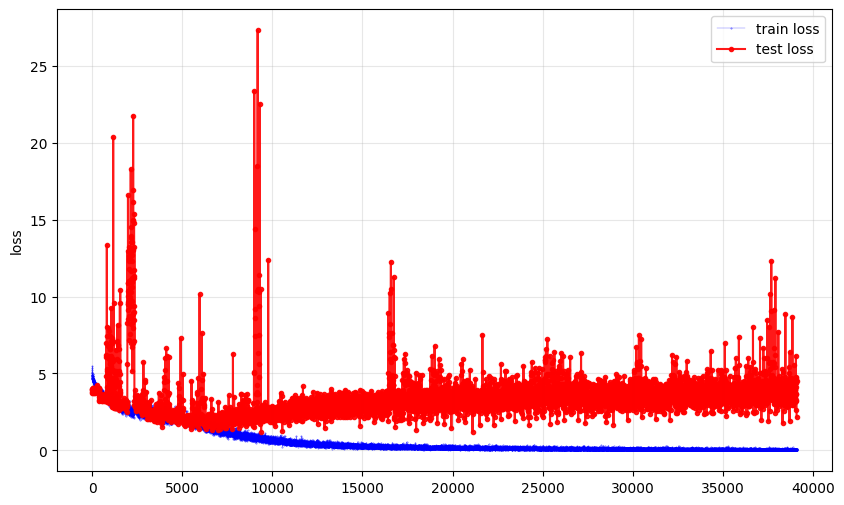

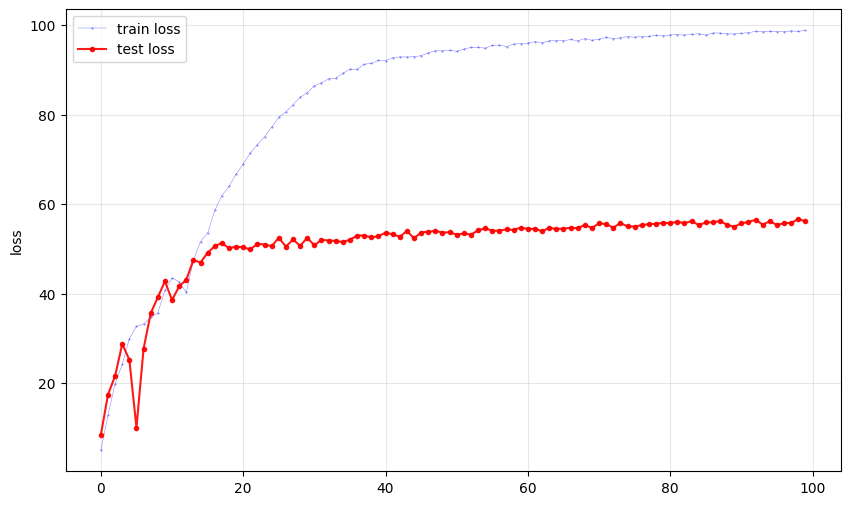

In [61]:
print("[ ] Finetuning model on CIFAR-100...")
finetuning(regnetx_3_2, train_loader, val_loader, device, 100)
print("[V] Model finetuned on CIFAR-100")

In [64]:
print("[ ] Entering pipeline...")
pipeline(regnetx_3_2, val_loader, device)
# pipeline(regnetx_16, val_loader, device)
print("[V] Pipeline finished")

[ ] Entering pipeline...

3. Validating model before binarizing...


Top-1 Accuracy: 55.779999999999994
Top-5 Accuracy: 80.9

2. Binarizing features...

3. Validating model after binarizing...
Top-1 Accuracy: 55.779999999999994
Top-5 Accuracy: 80.9

4. Avgpool and linear layers fusing...


AttributeError: 'RegNet' object has no attribute 'model'